# 03 — Train DistilBERT for Intent Classification

This notebook trains a DistilBERT model for the chatbot intent-classification module.

## Goals
- Train DistilBERT on the internal multi-source dataset.
- Evaluate on the internal test split.
- Evaluate generalization on external datasets such as CLINC150 and Banking77.
- Save the trained model, metrics, reports, and confusion matrix.

## Expected input files

```text
data/processed/train.csv
data/processed/val.csv
data/processed/test.csv
```

Each file should contain:

```text
instruction | intent | label
```


In [107]:
# Install once if needed:
#!pip install -q transformers datasets accelerate scikit-learn pandas matplotlib torch


In [108]:
import sys
print(sys.executable)
import torch
print(torch.__version__)
print(torch.cuda.is_available())

D:\conv_nlp_pipeline\venv\Scripts\python.exe
2.7.1+cu118
True


## 1. Imports and configuration


In [109]:
from pathlib import Path
import json
import random
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from datasets import Dataset, load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

RANDOM_SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_SEED)

PROJECT_DIR = Path("..") if Path("../data").exists() else Path(".")
DATA_DIR = PROJECT_DIR / "data" / "splits"
MODEL_DIR = PROJECT_DIR / "models" / "distilbert_intent"
REPORTS_DIR = PROJECT_DIR / "reports" / "distilbert_intent"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "distilbert-base-uncased"
TEXT_COL = "instruction"
LABEL_COL = "label"
INTENT_COL = "intent"

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)


Device: cuda


## 2. Load internal train / validation / test splits


In [110]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df   = pd.read_csv(DATA_DIR / "val.csv")
test_df  = pd.read_csv(DATA_DIR / "test.csv")

required_cols = {TEXT_COL, INTENT_COL, LABEL_COL}

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    missing = required_cols - set(df.columns)
    if missing:
        raise ValueError(f"{name} split is missing columns: {missing}")
    df[TEXT_COL] = df[TEXT_COL].astype(str)
    df[INTENT_COL] = df[INTENT_COL].astype(str)
    df[LABEL_COL] = df[LABEL_COL].astype(int)

print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

display(train_df.head())
display(train_df[INTENT_COL].value_counts().head(20).to_frame("n_samples"))


Train: (94418, 14)
Val  : (13993, 14)
Test : (13994, 14)


,instruction,response,intent,label,category,flags,source,mapping_method,word_count,char_count,has_placeholder,placeholder_count,is_external,is_heuristic
0,i have an idea to improve ur product can i sub...,Unquestionably! We greatly appreciate your ent...,submit_product_idea,30,feedback,BCIQ,bitext_retail,explicit_intent,12,52,False,0,False,False
1,I'd like to rwmove a fucking product from the ...,I'm truly sorry for any frustration you may ha...,remove_product,20,cart,BCIPWZ,bitext_retail,explicit_intent,14,67,False,0,False,False
2,"i bought this shirt and it doesn't fit, what i...",NaN,check_refund_policy,6,unknown,NaN,synthetic_ecommerce_nlpaug,explicit_intent+nlpaug_medium,26,123,False,0,True,False
3,WiKl this reset the feul trihs an 06 Silverado?,"Yes, when you clear the codes, the fuel trim r...",recover_password,19,unknown,NaN,amazon_single_qna_nlpaug,heuristic+nlpaug_heavy,9,47,False,0,True,True
4,i want a user account I'd like to create it,I'll get right on it! I'm here to assist you i...,create_account,8,account,BCLPQ,bitext_retail,explicit_intent,10,43,False,0,False,False


,n_samples
intent,
product_information,31317
contact_human_agent,5558
track_delivery,4048
delivery_time,3354
availability,3340
return_product,3014
check_refund_policy,2965
request_invoice,2531
recover_password,2005


## 3. Build label mappings


In [111]:
label_intent_df = (
    pd.concat([
        train_df[[LABEL_COL, INTENT_COL]],
        val_df[[LABEL_COL, INTENT_COL]],
        test_df[[LABEL_COL, INTENT_COL]],
    ])
    .drop_duplicates()
    .sort_values(LABEL_COL)
)

LABEL2ID = dict(zip(label_intent_df[INTENT_COL], label_intent_df[LABEL_COL]))
ID2LABEL = dict(zip(label_intent_df[LABEL_COL], label_intent_df[INTENT_COL]))
num_labels = len(ID2LABEL)

print("Number of labels:", num_labels)
print(list(ID2LABEL.items())[:10])

with open(REPORTS_DIR / "label_mappings.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": LABEL2ID, "id2label": ID2LABEL}, f, ensure_ascii=False, indent=2)


Number of labels: 37
[(0, 'add_product'), (1, 'availability'), (2, 'cancel_order'), (3, 'change_account'), (4, 'change_order'), (5, 'check_payment_methods'), (6, 'check_refund_policy'), (7, 'contact_human_agent'), (8, 'create_account'), (9, 'damaged_delivery')]


## 4. Convert data to Hugging Face Datasets


In [112]:
train_ds = Dataset.from_pandas(train_df[[TEXT_COL, LABEL_COL]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[[TEXT_COL, LABEL_COL]], preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[[TEXT_COL, LABEL_COL]], preserve_index=False)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=128,
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
val_ds   = val_ds.map(tokenize_batch, batched=True)
test_ds  = test_ds.map(tokenize_batch, batched=True)

train_ds = train_ds.rename_column(LABEL_COL, "labels")
val_ds   = val_ds.rename_column(LABEL_COL, "labels")
test_ds  = test_ds.rename_column(LABEL_COL, "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

print(train_ds)


Map:   0%|          | 0/94418 [00:00<?, ? examples/s]

Map:   0%|          | 0/13993 [00:00<?, ? examples/s]

Map:   0%|          | 0/13994 [00:00<?, ? examples/s]

Dataset({
    features: ['instruction', 'labels', 'input_ids', 'attention_mask'],
    num_rows: 94418
})


## 5. Load model


In [113]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=num_labels,
    id2label={int(k): v for k, v in ID2LABEL.items()},
    label2id={k: int(v) for k, v in LABEL2ID.items()},
)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## 6. Metrics


In [114]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro", zero_division=0),
        "f1_weighted": f1_score(labels, preds, average="weighted", zero_division=0),
    }


## 7. Train DistilBERT


In [115]:
training_args = TrainingArguments(
    output_dir=str(MODEL_DIR),
    evaluation_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=100,
    learning_rate=2e-5,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    weight_decay=0.02,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
    seed=RANDOM_SEED,
    lr_scheduler_type="cosine",
    label_smoothing_factor=0.1,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

trainer.train()


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.723300,0.706205,0.989566,0.989036,0.989549
2,0.696000,0.698643,0.991567,0.990626,0.991549
3,0.680300,0.695221,0.992496,0.992656,0.992512
4,0.676800,0.694645,0.992854,0.992543,0.992838
5,0.673200,0.694140,0.993139,0.992630,0.993131


Checkpoint destination directory ..\models\distilbert_intent\checkpoint-8853 already exists and is non-empty. Saving will proceed but saved results may be invalid.


TrainOutput(global_step=14755, training_loss=0.7342289372970596, metrics={'train_runtime': 6693.3555, 'train_samples_per_second': 70.531, 'train_steps_per_second': 2.204, 'total_flos': 9021939491494392.0, 'train_loss': 0.7342289372970596, 'epoch': 5.0})

## 8. Internal test evaluation


In [116]:
test_metrics = trainer.evaluate(test_ds)
print(test_metrics)

with open(REPORTS_DIR / "internal_test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(test_metrics, f, indent=2)


{'eval_loss': 0.6927486062049866, 'eval_accuracy': 0.9929969987137345, 'eval_f1_macro': 0.9920251209540847, 'eval_f1_weighted': 0.9930067334390115, 'eval_runtime': 63.8552, 'eval_samples_per_second': 219.152, 'eval_steps_per_second': 6.859, 'epoch': 5.0}


In [117]:
pred_output = trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=1)

target_names = [ID2LABEL[i] for i in sorted(ID2LABEL.keys())]

report_text = classification_report(
    y_true,
    y_pred,
    target_names=target_names,
    digits=4,
    zero_division=0,
)

print(report_text)

report_df = pd.DataFrame(
    classification_report(
        y_true,
        y_pred,
        target_names=target_names,
        digits=4,
        zero_division=0,
        output_dict=True,
    )
).transpose()

display(report_df)
report_df.to_csv(REPORTS_DIR / "internal_classification_report.csv", encoding="utf-8")

with open(REPORTS_DIR / "internal_classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)


                                precision    recall  f1-score   support

                   add_product     1.0000    1.0000    1.0000       143
                  availability     0.9961    0.9941    0.9951       512
                  cancel_order     0.9955    0.9778    0.9865       225
                change_account     0.9925    1.0000    0.9962       264
                  change_order     1.0000    0.9964    0.9982       276
         check_payment_methods     1.0000    0.9967    0.9983       300
           check_refund_policy     0.9873    0.9769    0.9820       476
           contact_human_agent     0.9940    0.9917    0.9928       839
                create_account     1.0000    1.0000    1.0000       284
              damaged_delivery     0.9617    0.9658    0.9638       234
                delete_account     1.0000    0.9965    0.9983       287
                 delivery_time     0.9980    0.9959    0.9969       491
              exchange_product     1.0000    1.0000    1.0000  

,precision,recall,f1-score,support
add_product,1.000000,1.000000,1.000000,143.000000
availability,0.996086,0.994141,0.995112,512.000000
cancel_order,0.995475,0.977778,0.986547,225.000000
change_account,0.992481,1.000000,0.996226,264.000000
change_order,1.000000,0.996377,0.998185,276.000000
check_payment_methods,1.000000,0.996667,0.998331,300.000000
check_refund_policy,0.987261,0.976891,0.982049,476.000000
contact_human_agent,0.994026,0.991657,0.992840,839.000000
create_account,1.000000,1.000000,1.000000,284.000000
damaged_delivery,0.961702,0.965812,0.963753,234.000000


## 9. Confusion matrix


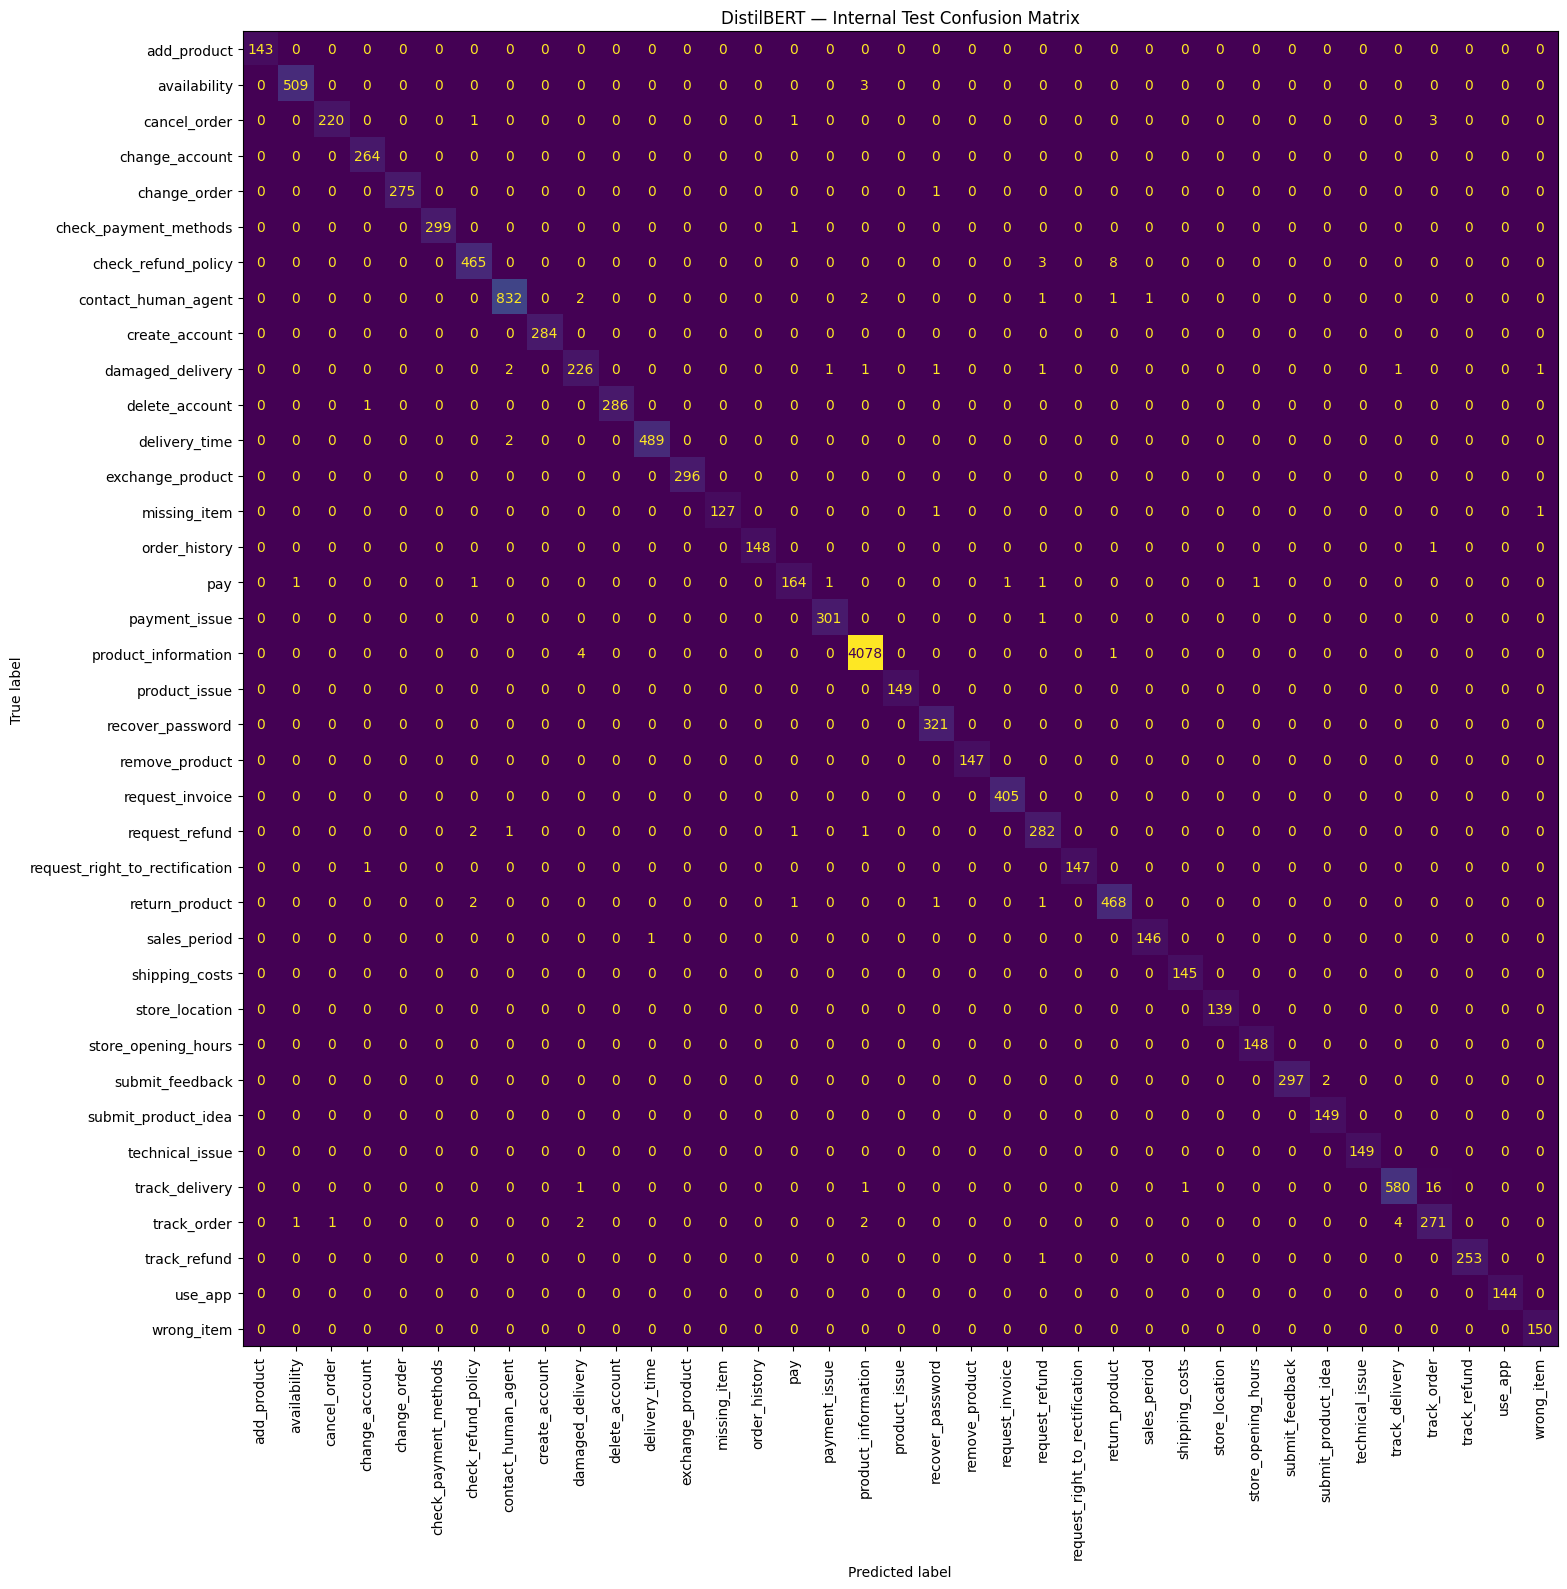

In [118]:
cm = confusion_matrix(y_true, y_pred, labels=sorted(ID2LABEL.keys()))

fig, ax = plt.subplots(figsize=(16, 16))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(ax=ax, xticks_rotation=90, values_format="d", colorbar=False)
plt.title("DistilBERT — Internal Test Confusion Matrix")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "internal_confusion_matrix.png", dpi=200)
plt.show()


## 10. External evaluation strategy

External datasets do not use the same labels as the project.

We use a mapping dictionary:

```text
external_intent -> project_canonical_intent
```

Only mapped labels are evaluated.  
Unmapped labels are ignored as out-of-scope.


In [119]:
def predict_texts_distilbert(texts):
    temp_df = pd.DataFrame({TEXT_COL: list(texts)})
    ds = Dataset.from_pandas(temp_df, preserve_index=False)
    ds = ds.map(tokenize_batch, batched=True)
    preds = trainer.predict(ds).predictions
    pred_ids = np.argmax(preds, axis=1)
    return [ID2LABEL[int(i)] for i in pred_ids]


def evaluate_external_dataset(external_df, text_col, external_intent_col, mapping, dataset_name):
    df = external_df.copy()
    df[text_col] = df[text_col].astype(str)
    df[external_intent_col] = df[external_intent_col].astype(str)

    df["mapped_intent"] = df[external_intent_col].map(mapping)
    df = df.dropna(subset=["mapped_intent"]).copy()
    df = df[df["mapped_intent"].isin(LABEL2ID)].copy()

    if df.empty:
        print(f"No mapped samples available for {dataset_name}. Update the mapping dictionary.")
        return None

    df["y_true"] = df["mapped_intent"]
    df["y_pred"] = predict_texts_distilbert(df[text_col].tolist())

    labels = sorted(df["y_true"].unique())

    metrics = {
        "dataset": dataset_name,
        "n_samples": int(len(df)),
        "accuracy": accuracy_score(df["y_true"], df["y_pred"]),
        "f1_macro": f1_score(df["y_true"], df["y_pred"], average="macro", zero_division=0),
        "f1_weighted": f1_score(df["y_true"], df["y_pred"], average="weighted", zero_division=0),
    }

    print(metrics)

    report_txt = classification_report(
        df["y_true"],
        df["y_pred"],
        labels=labels,
        digits=4,
        zero_division=0,
    )

    print(report_txt)

    safe_name = dataset_name.lower().replace(" ", "_")
    df.to_csv(REPORTS_DIR / f"external_{safe_name}_predictions.csv", index=False, encoding="utf-8")

    with open(REPORTS_DIR / f"external_{safe_name}_metrics.json", "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2)

    with open(REPORTS_DIR / f"external_{safe_name}_classification_report.txt", "w", encoding="utf-8") as f:
        f.write(report_txt)

    return df, metrics


## 11. External evaluation — CLINC150


In [120]:
try:
    clinc = load_dataset("clinc_oos", "plus")
    clinc_test = clinc["test"].to_pandas()

    clinc_label_names = clinc["test"].features["intent"].names
    clinc_test["intent_name"] = clinc_test["intent"].apply(lambda x: clinc_label_names[int(x)])

    print("CLINC150 test shape:", clinc_test.shape)
    display(clinc_test[["text", "intent_name"]].head())
    display(clinc_test["intent_name"].value_counts().head(30).to_frame("n_samples"))

except Exception as e:
    print("Could not load CLINC150:", e)
    clinc_test = None


CLINC150 test shape: (5500, 3)


,text,intent_name
0,how would you say fly in italian,translate
1,what's the spanish word for pasta,translate
2,how would they say butter in zambia,translate
3,how do you say fast in spanish,translate
4,what's the word for trees in norway,translate


,n_samples
intent_name,
oos,1000
pin_change,30
account_blocked,30
what_song,30
international_fees,30
last_maintenance,30
meeting_schedule,30
ingredients_list,30
report_fraud,30


In [121]:
# Adapt this mapping to your canonical intent names.
# Keep only labels that exist in LABEL2ID.

CLINC_TO_PROJECT_INTENT = {
    "order_status"  : "track_order",
    "pin_change"    : "change_account",
    "account_blocked": "contact_human_agent",
    "report_fraud"  : "payment_issue",
    "min_payment"   : "check_payment_methods",
    "damaged_card"  : "payment_issue",
    "routing"       : "check_payment_methods",
}

CLINC_TO_PROJECT_INTENT = {
    k: v for k, v in CLINC_TO_PROJECT_INTENT.items()
    if v is not None and v in LABEL2ID
}

print("Mapped CLINC intents:", CLINC_TO_PROJECT_INTENT)

if clinc_test is not None:
    clinc_results = evaluate_external_dataset(
        external_df=clinc_test,
        text_col="text",
        external_intent_col="intent_name",
        mapping=CLINC_TO_PROJECT_INTENT,
        dataset_name="CLINC150",
    )


Mapped CLINC intents: {'order_status': 'track_order', 'pin_change': 'change_account', 'account_blocked': 'contact_human_agent', 'report_fraud': 'payment_issue', 'min_payment': 'check_payment_methods', 'damaged_card': 'payment_issue', 'routing': 'check_payment_methods'}


Map:   0%|          | 0/210 [00:00<?, ? examples/s]

{'dataset': 'CLINC150', 'n_samples': 210, 'accuracy': 0.20952380952380953, 'f1_macro': 0.09751286855764468, 'f1_weighted': 0.26683004273622607}
                       precision    recall  f1-score   support

       change_account     0.3667    0.3667    0.3667        30
check_payment_methods     0.5714    0.0667    0.1194        60
  contact_human_agent     0.0000    0.0000    0.0000        30
        payment_issue     1.0000    0.1667    0.2857        60
          track_order     0.7600    0.6333    0.6909        30

            micro avg     0.6027    0.2095    0.3110       210
            macro avg     0.5396    0.2467    0.2925       210
         weighted avg     0.6099    0.2095    0.2668       210



## 12. External evaluation 


In [122]:
import pandas as pd
import re
from pathlib import Path

# ================================
# 1. Load Kaggle external dataset
# ================================

ecom_ext = pd.read_csv(DATA_DIR / "test_externe.csv") 
 

print(ecom_ext.shape)
print(ecom_ext.columns)
display(ecom_ext.head())

(153464, 2)
Index(['instructions', 'intents'], dtype='object')


,instructions,intents
0,what do i need to do to change to the gold acc...,account_management
1,i try to modify the shippig address,account_management
2,how cani change order {{order number}}?,order_management
3,how could i enter afucking delivery address,account_management
4,can uhelp me canceling order {{order number}},order_management


In [123]:
# ================================
# 2. Detect text and intent columns
# ================================

possible_text_cols = ["utterance", "text", "query", "sentence", "customer_query", "instructions"]
possible_intent_cols = ["intents", "label", "category", "intent_name"]

text_col = next((c for c in possible_text_cols if c in ecom_ext.columns), None)
intent_col = next((c for c in possible_intent_cols if c in ecom_ext.columns), None)

print("Detected text column:", text_col)
print("Detected intent column:", intent_col)

if text_col is None or intent_col is None:
    raise ValueError("Please manually set text_col and intent_col according to your CSV columns.")

print(ecom_ext[intent_col].value_counts())

Detected text column: instructions
Detected intent column: intents
intents
issue_support            27799
order_tracking           17266
account_management       17083
product_inquiry          16151
order_management          9775
out_of_scope              9020
billing_and_payment       8949
place_order               8305
submit_feedback           6120
delivery_options          5816
customer_care_support     5668
remove_from_cart          5468
store_information         5438
shipping_cost             5383
add_to_cart               5223
Name: count, dtype: int64


In [124]:
# ================================
# 3. Placeholder normalization
# ================================

def normalize_placeholders(text):
    text = str(text)

    text = re.sub(r"\b[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}\b", " [EMAIL] ", text)
    text = re.sub(r"\b(?:\+?\d[\d\s\-().]{7,}\d)\b", " [PHONE] ", text)
    text = re.sub(r"\b\d{4,}\b", " [NUMBER] ", text)
    text = re.sub(r"\b(order|ord)[-_ ]?#?\d+\b", " [ORDER_ID] ", text, flags=re.I)
    text = re.sub(r"\$\s?\d+|\d+\s?(usd|eur|dt|tnd|£|€)", " [PRICE] ", text, flags=re.I)
    text = re.sub(r"\b\d{1,2}[/-]\d{1,2}[/-]\d{2,4}\b", " [DATE] ", text)

    text = re.sub(r"\s+", " ", text).strip()
    return text


ecom_ext["text_clean"] = ecom_ext[text_col].apply(normalize_placeholders)

display(ecom_ext[[text_col, "text_clean", intent_col]].head(10))

,instructions,text_clean,intents
0,what do i need to do to change to the gold acc...,what do i need to do to change to the gold acc...,account_management
1,i try to modify the shippig address,i try to modify the shippig address,account_management
2,how cani change order {{order number}}?,how cani change order {{order number}}?,order_management
3,how could i enter afucking delivery address,how could i enter afucking delivery address,account_management
4,can uhelp me canceling order {{order number}},can uhelp me canceling order {{order number}},order_management
5,i need assistance to set the delivery address up,i need assistance to set the delivery address up,account_management
6,where to download invoice #00108?,where to download invoice # [NUMBER] ?,billing_and_payment
7,i do not know how i could ask for goddamn refunds,i do not know how i could ask for goddamn refunds,issue_support
8,i do not know how to look for the bill from {{...,i do not know how to look for the bill from {{...,billing_and_payment
9,"i cannot remember my user key, i want to reset it","i cannot remember my user key, i want to reset it",account_management


In [125]:
# ================================
# 4. Map external intents to project intents
# ================================

print("External intents:")
print(sorted(ecom_ext[intent_col].astype(str).unique()))

External intents:
['account_management', 'add_to_cart', 'billing_and_payment', 'customer_care_support', 'delivery_options', 'issue_support', 'order_management', 'order_tracking', 'out_of_scope', 'place_order', 'product_inquiry', 'remove_from_cart', 'shipping_cost', 'store_information', 'submit_feedback']


In [126]:
KAGGLE_TO_PROJECT_INTENT = {
    "issue_support"       : "contact_human_agent",
    "order_tracking"      : "track_order",
    "account_management"  : "change_account",
    "product_inquiry"     : "product_information",   # was MISSING — biggest fix
    "order_management"    : "change_order",
    "billing_and_payment" : "check_payment_methods",
    "submit_feedback"     : "submit_feedback",
    "delivery_options"    : "track_delivery",
    "store_information"   : "store_location",
    "shipping_cost"       : "shipping_costs",
    "customer_care_support": "contact_human_agent",
}

In [127]:
# Keep only mapped intents that exist in your project labels

KAGGLE_TO_PROJECT_INTENT = {
    k: v for k, v in KAGGLE_TO_PROJECT_INTENT.items()
    if v is not None and v in LABEL2ID
}

print("Final mapping:", KAGGLE_TO_PROJECT_INTENT)

Final mapping: {'issue_support': 'contact_human_agent', 'order_tracking': 'track_order', 'account_management': 'change_account', 'product_inquiry': 'product_information', 'order_management': 'change_order', 'billing_and_payment': 'check_payment_methods', 'submit_feedback': 'submit_feedback', 'delivery_options': 'track_delivery', 'store_information': 'store_location', 'shipping_cost': 'shipping_costs', 'customer_care_support': 'contact_human_agent'}


In [128]:
# ================================
# 6. External evaluation
# ================================

kaggle_results = evaluate_external_dataset(
    external_df=ecom_ext,
    text_col="text_clean",
    external_intent_col=intent_col,
    mapping=KAGGLE_TO_PROJECT_INTENT,
    dataset_name="Kaggle_Ecommerce_Intent",
)

Map:   0%|          | 0/125448 [00:00<?, ? examples/s]

{'dataset': 'Kaggle_Ecommerce_Intent', 'n_samples': 125448, 'accuracy': 0.3001642114661055, 'f1_macro': 0.11310488573803255, 'f1_weighted': 0.3880996373304842}
                       precision    recall  f1-score   support

       change_account     0.9137    0.2059    0.3360     17083
         change_order     0.7253    0.3693    0.4894      9775
check_payment_methods     0.8090    0.2698    0.4046      8949
  contact_human_agent     0.5315    0.1705    0.2582     33467
  product_information     0.6503    0.5172    0.5761     16151
       shipping_costs     0.9002    0.2597    0.4031      5383
       store_location     0.8205    0.2034    0.3260      5438
      submit_feedback     0.9397    0.5067    0.6584      6120
       track_delivery     0.2376    0.6811    0.3523      5816
          track_order     0.7111    0.2599    0.3807     17266

            micro avg     0.5831    0.3002    0.3963    125448
            macro avg     0.7239    0.3443    0.4185    125448
         weighted a

## 13. Save final model


In [129]:
trainer.save_model(MODEL_DIR / "best_model")
tokenizer.save_pretrained(MODEL_DIR / "best_model")

with open(MODEL_DIR / "label_mappings.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": LABEL2ID, "id2label": ID2LABEL}, f, ensure_ascii=False, indent=2)

print("Saved DistilBERT model to:", MODEL_DIR / "best_model")


Saved DistilBERT model to: ..\models\distilbert_intent\best_model


## 14. Report note


DistilBERT is used as a supervised Transformer baseline for intent classification.  
The model is fine-tuned on the internal multi-source dataset and evaluated on the internal test split.  
To estimate external generalization, it is also tested on selected samples from CLINC150 and Banking77 after mapping compatible external intents to the project's canonical intent space.
